In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [5]:
import zipfile

zip_path = "/content/archive (5).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Extracted successfully!")

Extracted successfully!


In [6]:
import os
print(os.listdir('/content'))

['.config', 'Training', 'archive (5).zip', 'Testing', 'sample_data']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32


dataset_path = "/content/Training"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/Testing",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 1600 images belonging to 4 classes.


In [12]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Block 2
model.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Block 3
model.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Fully Connected
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [14]:
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.5710 - loss: 0.9918 - val_accuracy: 0.5268 - val_loss: 1.0384
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.7190 - loss: 0.7052 - val_accuracy: 0.6723 - val_loss: 0.7536
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.7536 - loss: 0.6367 - val_accuracy: 0.6491 - val_loss: 0.8212
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 385s 3s/step - accuracy: 0.7643 - loss: 0.5916 - val_accuracy: 0.6982 - val_loss: 0.6877
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 386s 3s/step - accuracy: 0.8009 - loss: 0.5141 - val_accuracy: 0.7429 - val_loss: 0.5966


In [18]:
loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 792ms/step - accuracy: 0.7518 - loss: 0.5966
Validation Accuracy: 0.7517856955528259


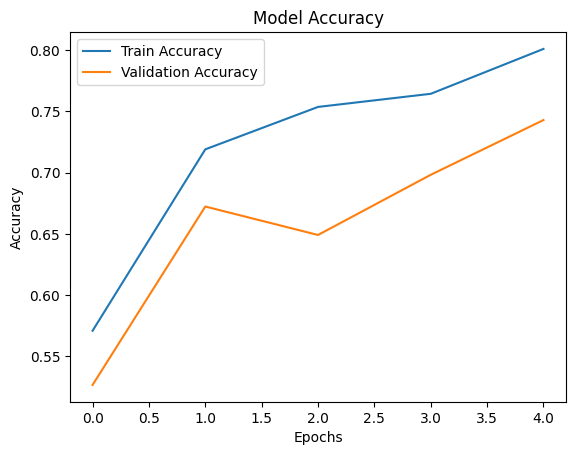

In [19]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy", "Validation Accuracy"])

plt.show()

In [20]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 640ms/step - accuracy: 0.7119 - loss: 0.8893
Test Accuracy: 0.7118750214576721


Using image: /content/Testing/notumor/Te-no_277.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


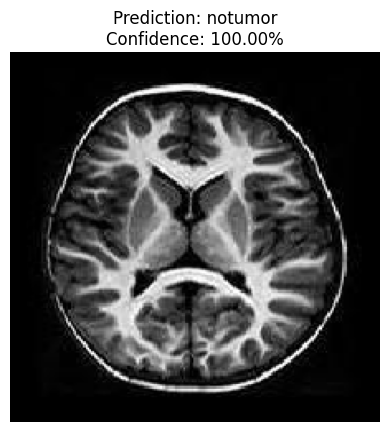

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Folder path
folder_path = "/content/Testing"

# Auto pick image
class_name = os.listdir(folder_path)[0]
img_name = os.listdir(os.path.join(folder_path, class_name))[0]
img_path = os.path.join(folder_path, class_name, img_name)

print("Using image:", img_path)

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)
classes = list(train_generator.class_indices.keys())

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 829ms/step


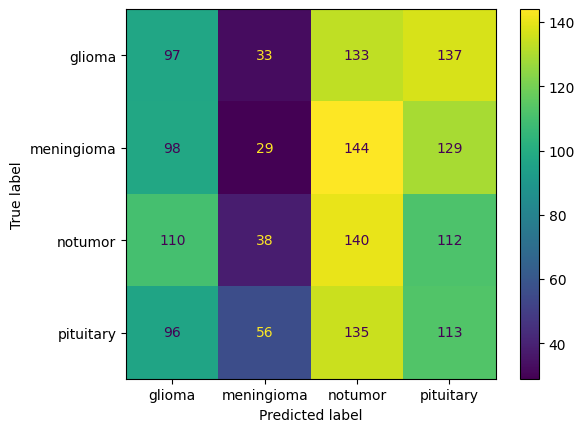

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(train_generator.class_indices.keys()))
disp.plot()
plt.show()